# Lab 2 - Preparação dos Dados
## Importação e carregamento

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df_treino = pd.read_csv('../material/lab2_cmc13_dados_treinamento.csv')
df_teste = pd.read_csv('../material/lab2_cmc13_dados_teste.csv')

## Diagnóstico




In [94]:
print(f'Treino: {df_treino.shape[0]} linhas, {df_treino.shape[1]} colunas')
print(f'Teste:  {df_teste.shape[0]} linhas, {df_teste.shape[1]} colunas')
df_treino.head()

Treino: 440833 linhas, 12 colunas
Teste:  64374 linhas, 12 colunas


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [95]:
# Linhas completamente vazias (todos os valores NaN)
linhas_vazias = df_treino[df_treino.isnull().all(axis=1)]
print(f"Linhas completamente vazias: {len(linhas_vazias)}")
print(f"Índices: {linhas_vazias.index.tolist()}")
linhas_vazias
# Remover linhas completamente vazias
df_treino = df_treino.dropna(how='all').reset_index(drop=True)
print(f"Treino após remoção: {df_treino.shape[0]} linhas")

Linhas completamente vazias: 1
Índices: [199295]
Treino após remoção: 440832 linhas


In [96]:
df_treino.info()
print("------------")
df_teste.info()

<class 'pandas.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 48.5 MB
------------
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ---

In [97]:
print("=" * 80)
print("COMPARAÇÃO TREINO vs TESTE - LADO A LADO")
print("=" * 80)

for col in df_treino.columns:
    print(f"\n{'─' * 80}")
    print(f"  {col}")
    print(f"{'─' * 80}")
    
    is_numeric = pd.api.types.is_numeric_dtype(df_treino[col])
    
    if is_numeric:
        stats = pd.DataFrame({
            'Treino': [
                df_treino[col].count(),
                df_treino[col].isnull().sum(),
                df_treino[col].nunique(),
                df_treino[col].mean(),
                df_treino[col].std(),
                df_treino[col].min(),
                df_treino[col].quantile(0.25),
                df_treino[col].median(),
                df_treino[col].quantile(0.75),
                df_treino[col].max(),
                df_treino[col].skew(),
                df_treino[col].kurtosis()
            ],
            'Teste': [
                df_teste[col].count(),
                df_teste[col].isnull().sum(),
                df_teste[col].nunique(),
                df_teste[col].mean(),
                df_teste[col].std(),
                df_teste[col].min(),
                df_teste[col].quantile(0.25),
                df_teste[col].median(),
                df_teste[col].quantile(0.75),
                df_teste[col].max(),
                df_teste[col].skew(),
                df_teste[col].kurtosis()
            ]
        }, index=['count', 'missing', 'únicos', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis'])
        print(stats.to_string())
    else:
        # Categóricos: valores únicos lado a lado + contagens
        vals_treino = df_treino[col].value_counts(dropna=False)
        vals_teste = df_teste[col].value_counts(dropna=False)
        
        todos = sorted(set(vals_treino.index) | set(vals_teste.index), key=str)
        
        comparacao = pd.DataFrame({
            'Treino (n)': [vals_treino.get(v, 0) for v in todos],
            'Treino (%)': [f"{vals_treino.get(v, 0) / len(df_treino) * 100:.1f}%" for v in todos],
            'Teste (n)': [vals_teste.get(v, 0) for v in todos],
            'Teste (%)': [f"{vals_teste.get(v, 0) / len(df_teste) * 100:.1f}%" for v in todos],
        }, index=todos)
        
        print(f"  Missing treino: {df_treino[col].isnull().sum()}  |  Missing teste: {df_teste[col].isnull().sum()}")
        print(comparacao.to_string())

COMPARAÇÃO TREINO vs TESTE - LADO A LADO

────────────────────────────────────────────────────────────────────────────────
  CustomerID
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  6.437400e+04
missing        0.000000  0.000000e+00
únicos    440832.000000  6.437400e+04
mean      225398.667955  3.218750e+04
std       129531.918550  1.858332e+04
min            2.000000  1.000000e+00
25%       113621.750000  1.609425e+04
50%       226125.500000  3.218750e+04
75%       337739.250000  4.828075e+04
max       449999.000000  6.437400e+04
skew          -0.018486 -7.746223e-17
kurtosis      -1.200644 -1.200000e+00

────────────────────────────────────────────────────────────────────────────────
  Age
────────────────────────────────────────────────────────────────────────────────
                 Treino         Teste
count     440832.000000  64374.000000
missing        0.000000      0.000000
únicos

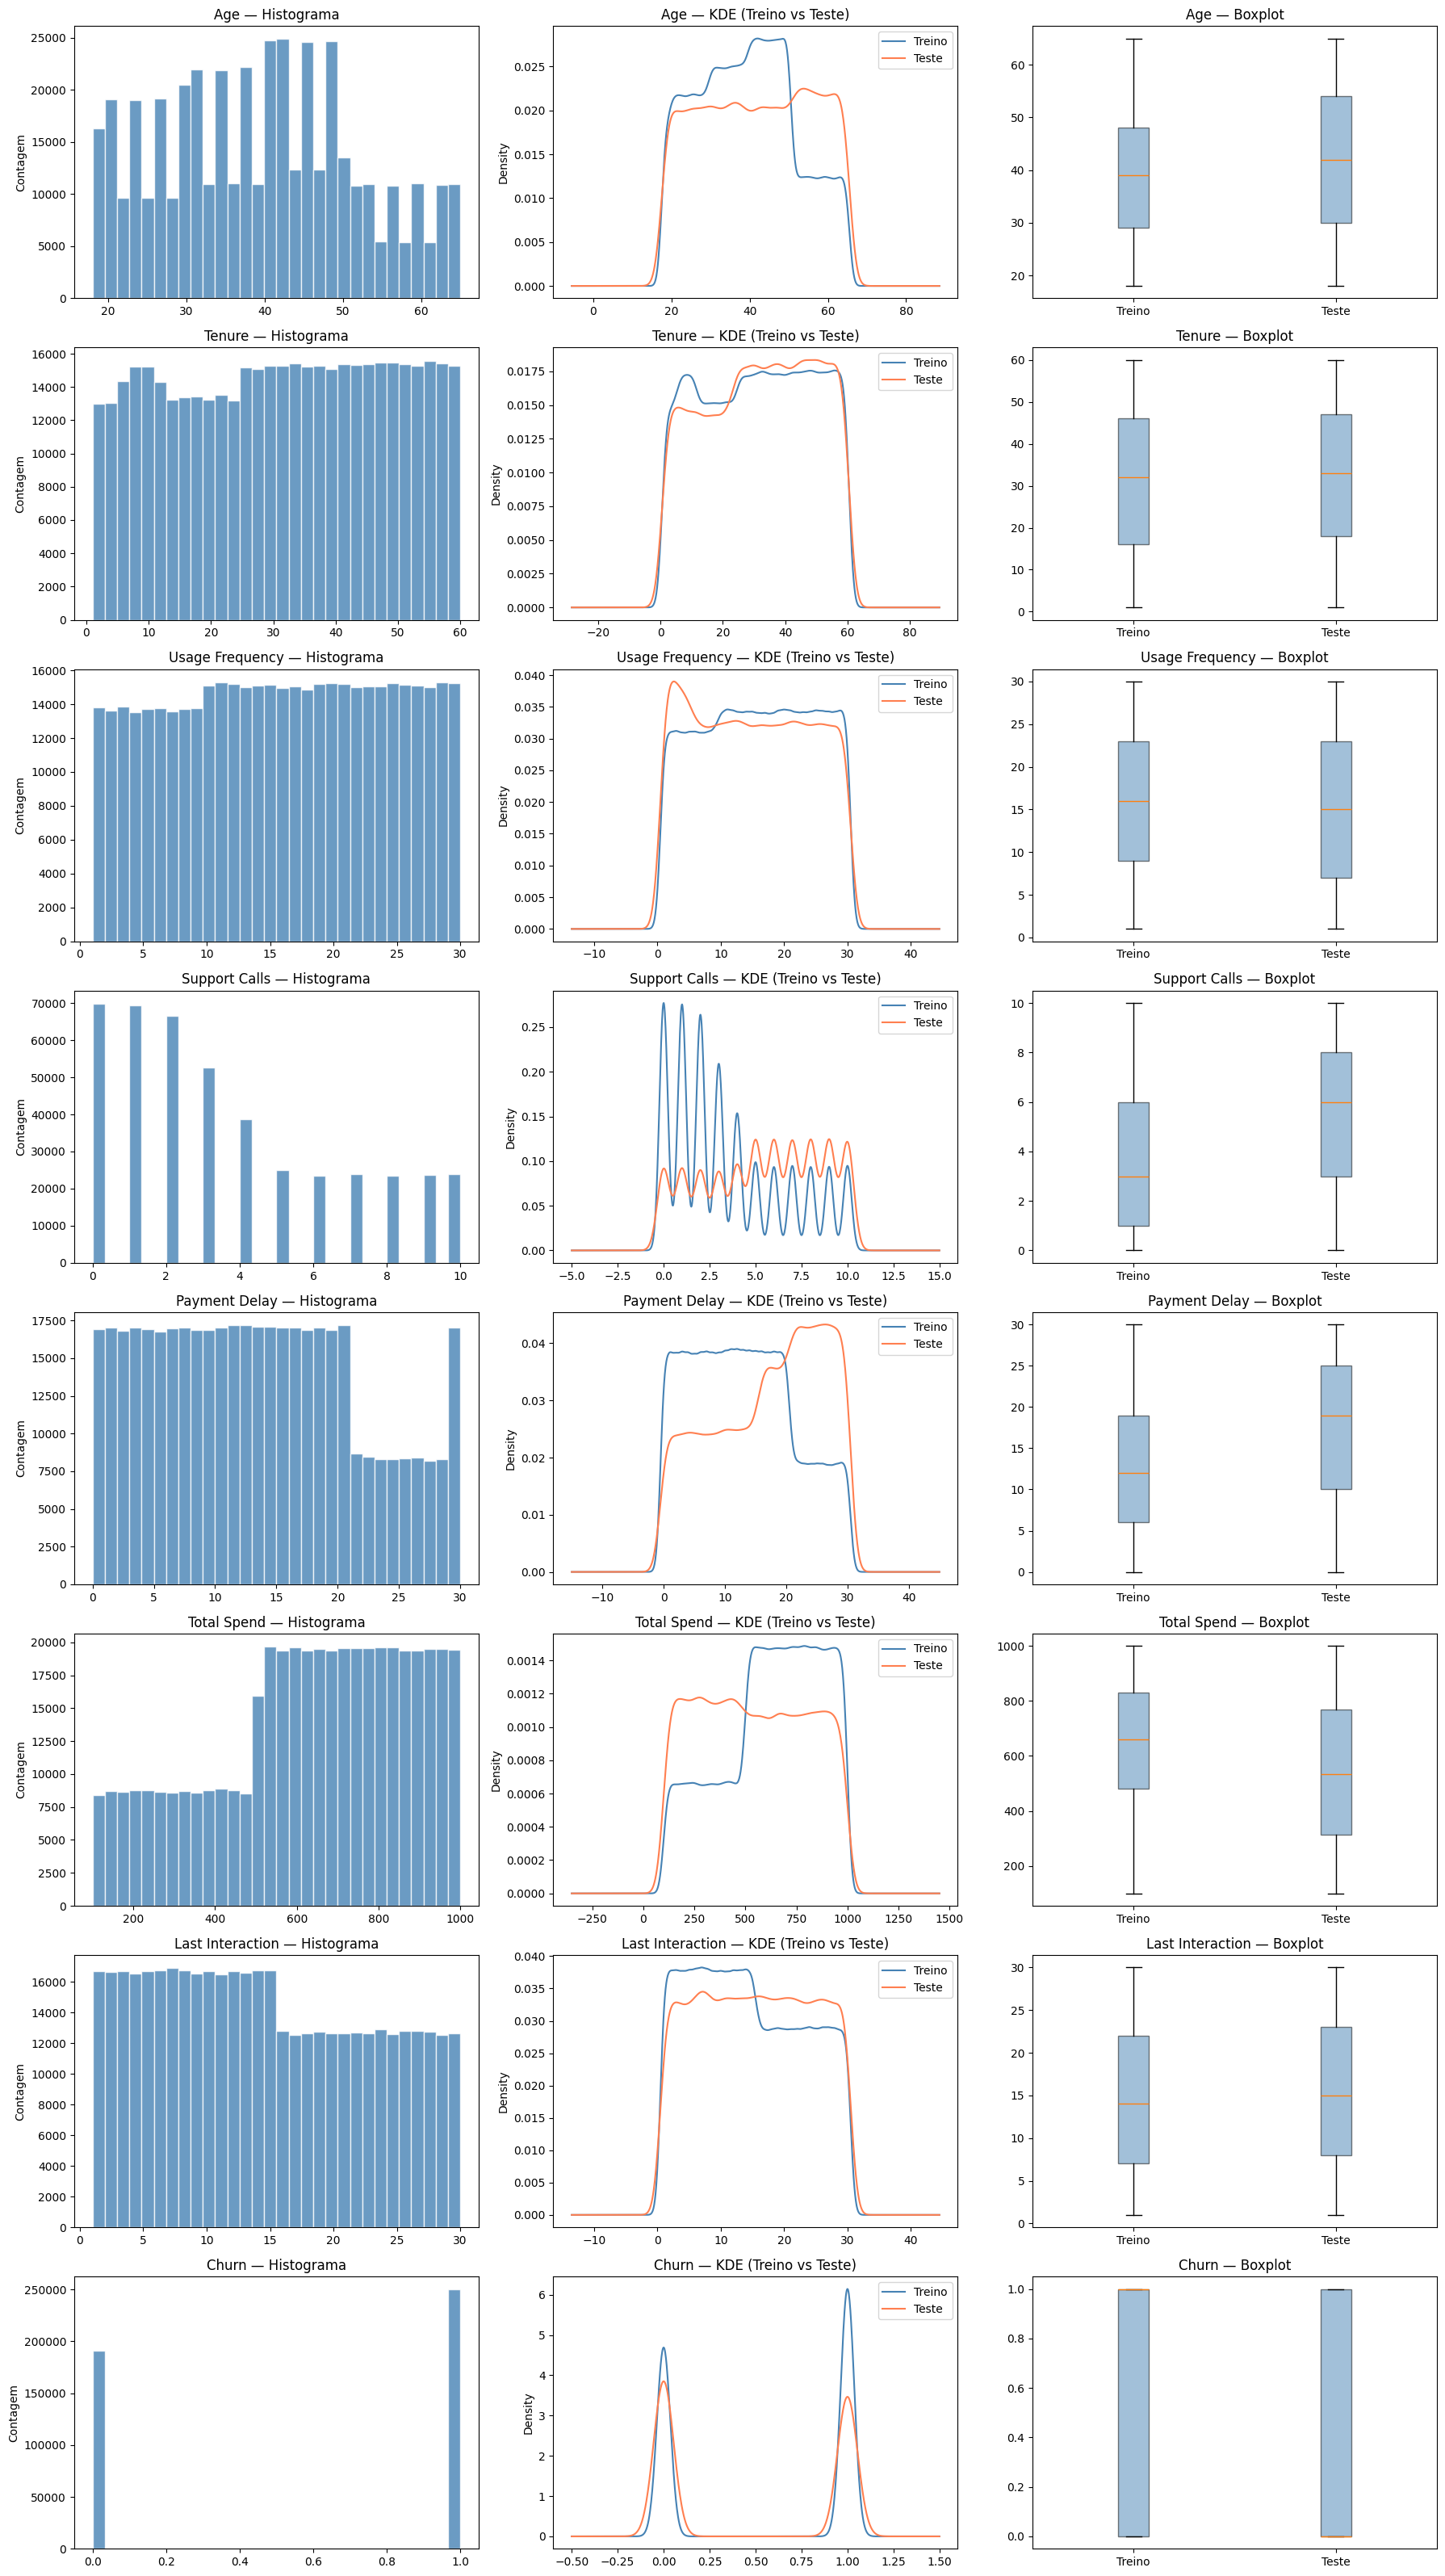

In [98]:
# Bloco 1 — Numéricas: Histograma + KDE + Boxplot (lado a lado)
cols_num = df_treino.select_dtypes(include='number').columns.drop('CustomerID')

fig, axes = plt.subplots(len(cols_num), 3, figsize=(18, 4 * len(cols_num)))

for i, col in enumerate(cols_num):
    # Histograma
    axes[i, 0].hist(df_treino[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col} — Histograma')
    axes[i, 0].set_ylabel('Contagem')
    
    # KDE
    df_treino[col].dropna().plot.kde(ax=axes[i, 1], color='steelblue', label='Treino')
    df_teste[col].dropna().plot.kde(ax=axes[i, 1], color='coral', label='Teste')
    axes[i, 1].set_title(f'{col} — KDE (Treino vs Teste)')
    axes[i, 1].legend()
    
    # Boxplot
    axes[i, 2].boxplot(
        [df_treino[col].dropna(), df_teste[col].dropna()],
        tick_labels=['Treino', 'Teste'], vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.5)
    )
    axes[i, 2].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

C:\Users\joaos\AppData\Local\Temp\ipykernel_62044\2768037508.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df_treino.select_dtypes(include='object').columns


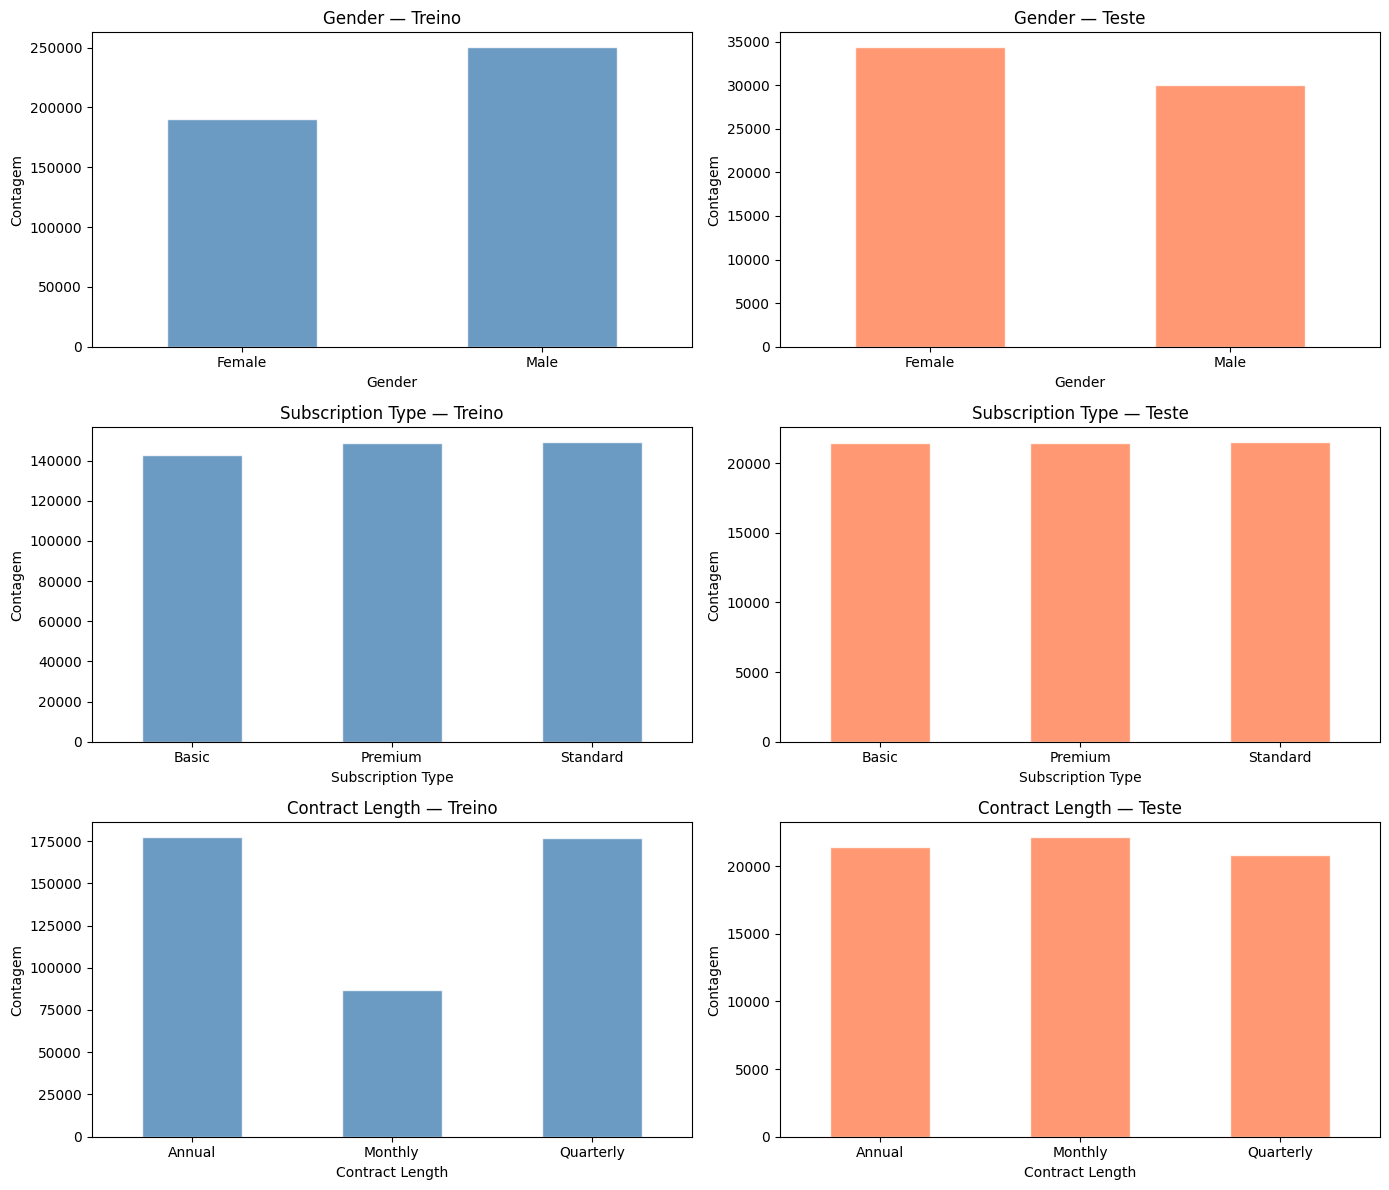

In [99]:
# Bloco 2 — Categóricas: Countplot (Treino vs Teste lado a lado)
cols_cat = df_treino.select_dtypes(include='object').columns

fig, axes = plt.subplots(len(cols_cat), 2, figsize=(14, 4 * len(cols_cat)))

for i, col in enumerate(cols_cat):
    # Treino
    df_treino[col].value_counts().sort_index().plot.bar(
        ax=axes[i, 0], color='steelblue', edgecolor='white', alpha=0.8
    )
    axes[i, 0].set_title(f'{col} — Treino')
    axes[i, 0].set_ylabel('Contagem')
    axes[i, 0].tick_params(axis='x', rotation=0)
    
    # Teste
    df_teste[col].value_counts().sort_index().plot.bar(
        ax=axes[i, 1], color='coral', edgecolor='white', alpha=0.8
    )
    axes[i, 1].set_title(f'{col} — Teste')
    axes[i, 1].set_ylabel('Contagem')
    axes[i, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

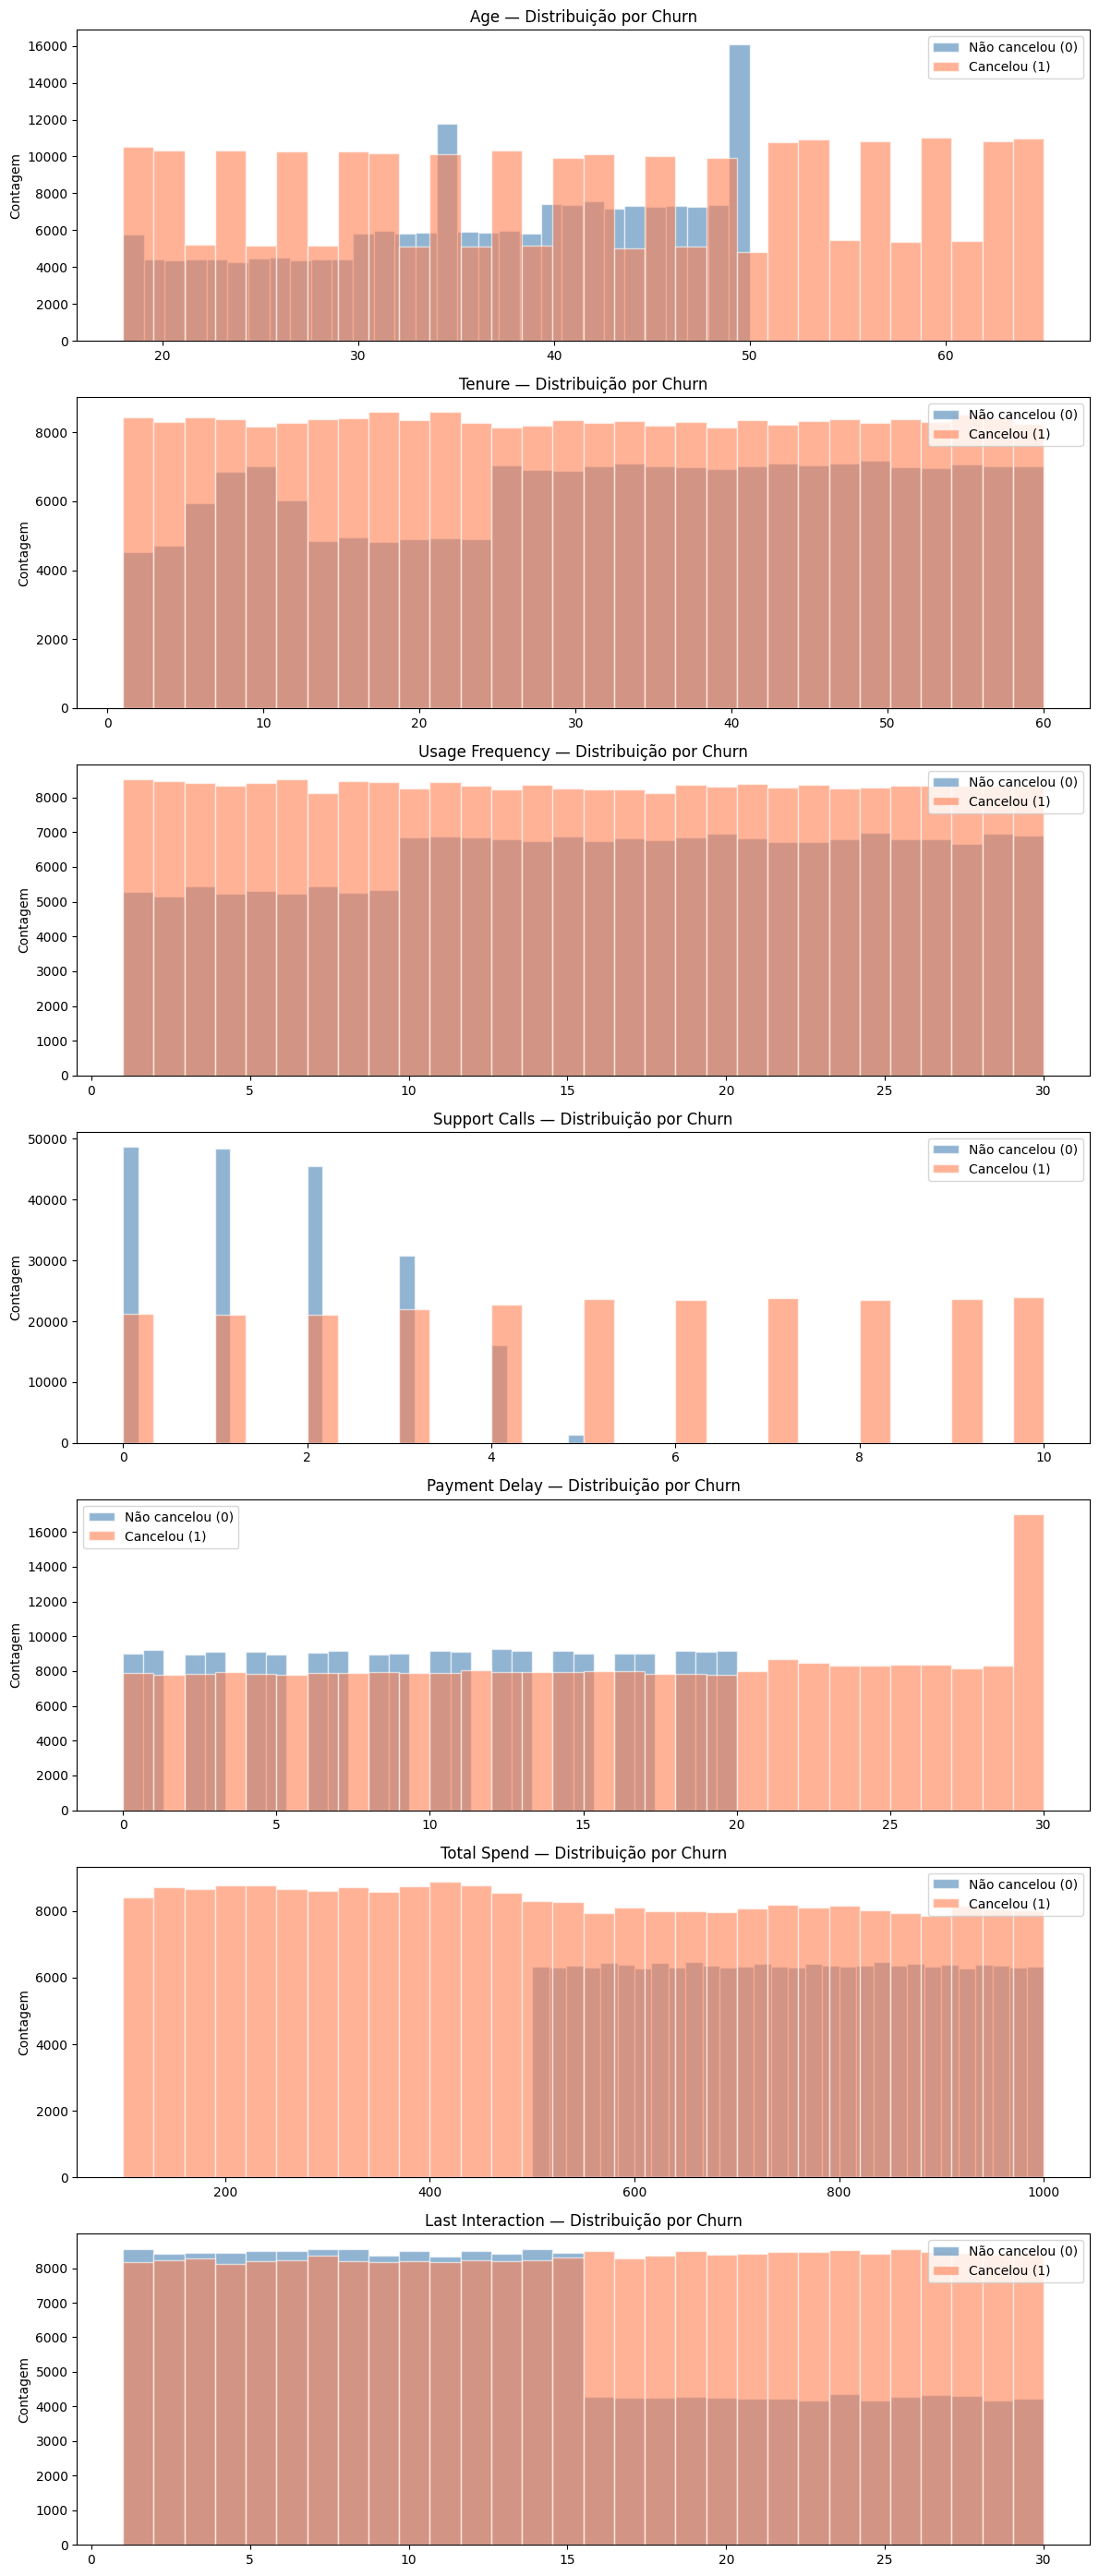

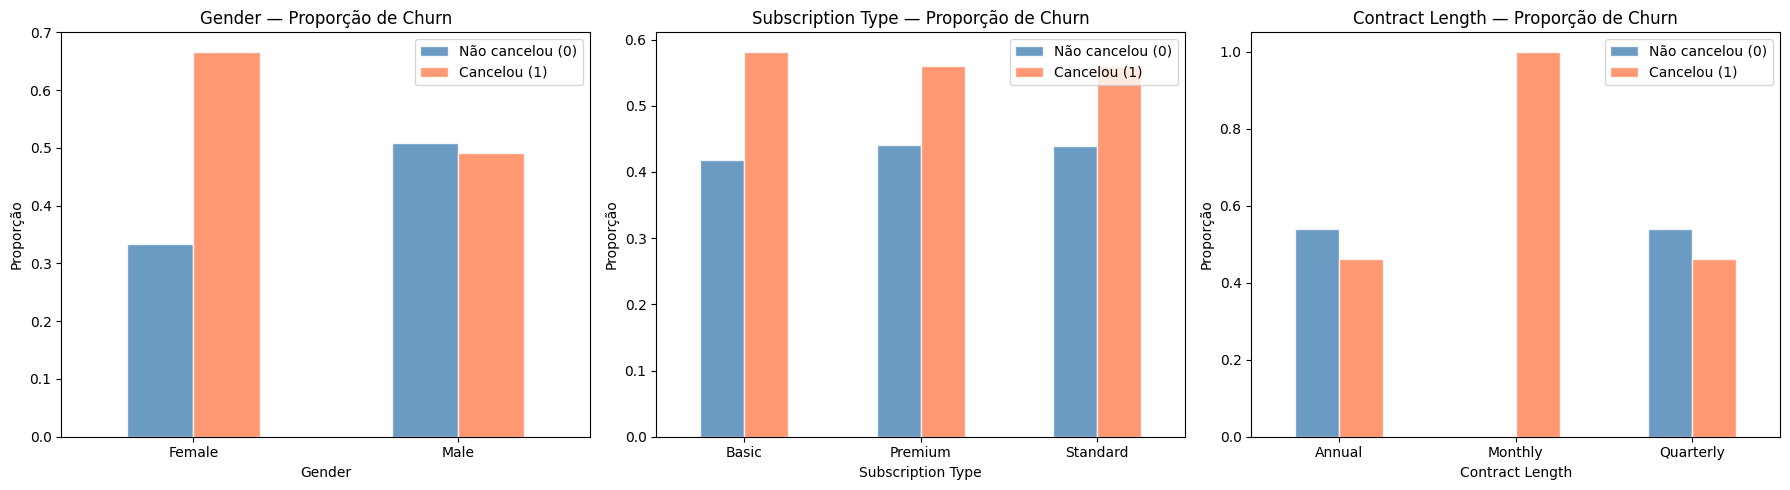

In [100]:
# Bloco 3 — Distribuição por Churn (numéricas: histograma colorido por classe)
fig, axes = plt.subplots(len(cols_num) - 1, 1, figsize=(12, 4 * (len(cols_num) - 1)))
# Exclui Churn da lista pois é a própria variável alvo
cols_features = [c for c in cols_num if c != 'Churn']

for i, col in enumerate(cols_features):
    ax = axes[i] if len(cols_features) > 1 else axes
    
    df_treino[df_treino['Churn'] == 0][col].dropna().plot.hist(
        ax=ax, bins=30, alpha=0.6, color='steelblue', label='Não cancelou (0)', edgecolor='white'
    )
    df_treino[df_treino['Churn'] == 1][col].dropna().plot.hist(
        ax=ax, bins=30, alpha=0.6, color='coral', label='Cancelou (1)', edgecolor='white'
    )
    ax.set_title(f'{col} — Distribuição por Churn')
    ax.set_ylabel('Contagem')
    ax.legend()

plt.tight_layout()
plt.show()

# Categóricas por Churn
fig, axes = plt.subplots(1, len(cols_cat), figsize=(6 * len(cols_cat), 5))

for i, col in enumerate(cols_cat):
    ax = axes[i] if len(cols_cat) > 1 else axes
    
    ct = pd.crosstab(df_treino[col], df_treino['Churn'], normalize='index')
    ct.plot.bar(ax=ax, color=['steelblue', 'coral'], edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} — Proporção de Churn')
    ax.set_ylabel('Proporção')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Não cancelou (0)', 'Cancelou (1)'])

plt.tight_layout()
plt.show()

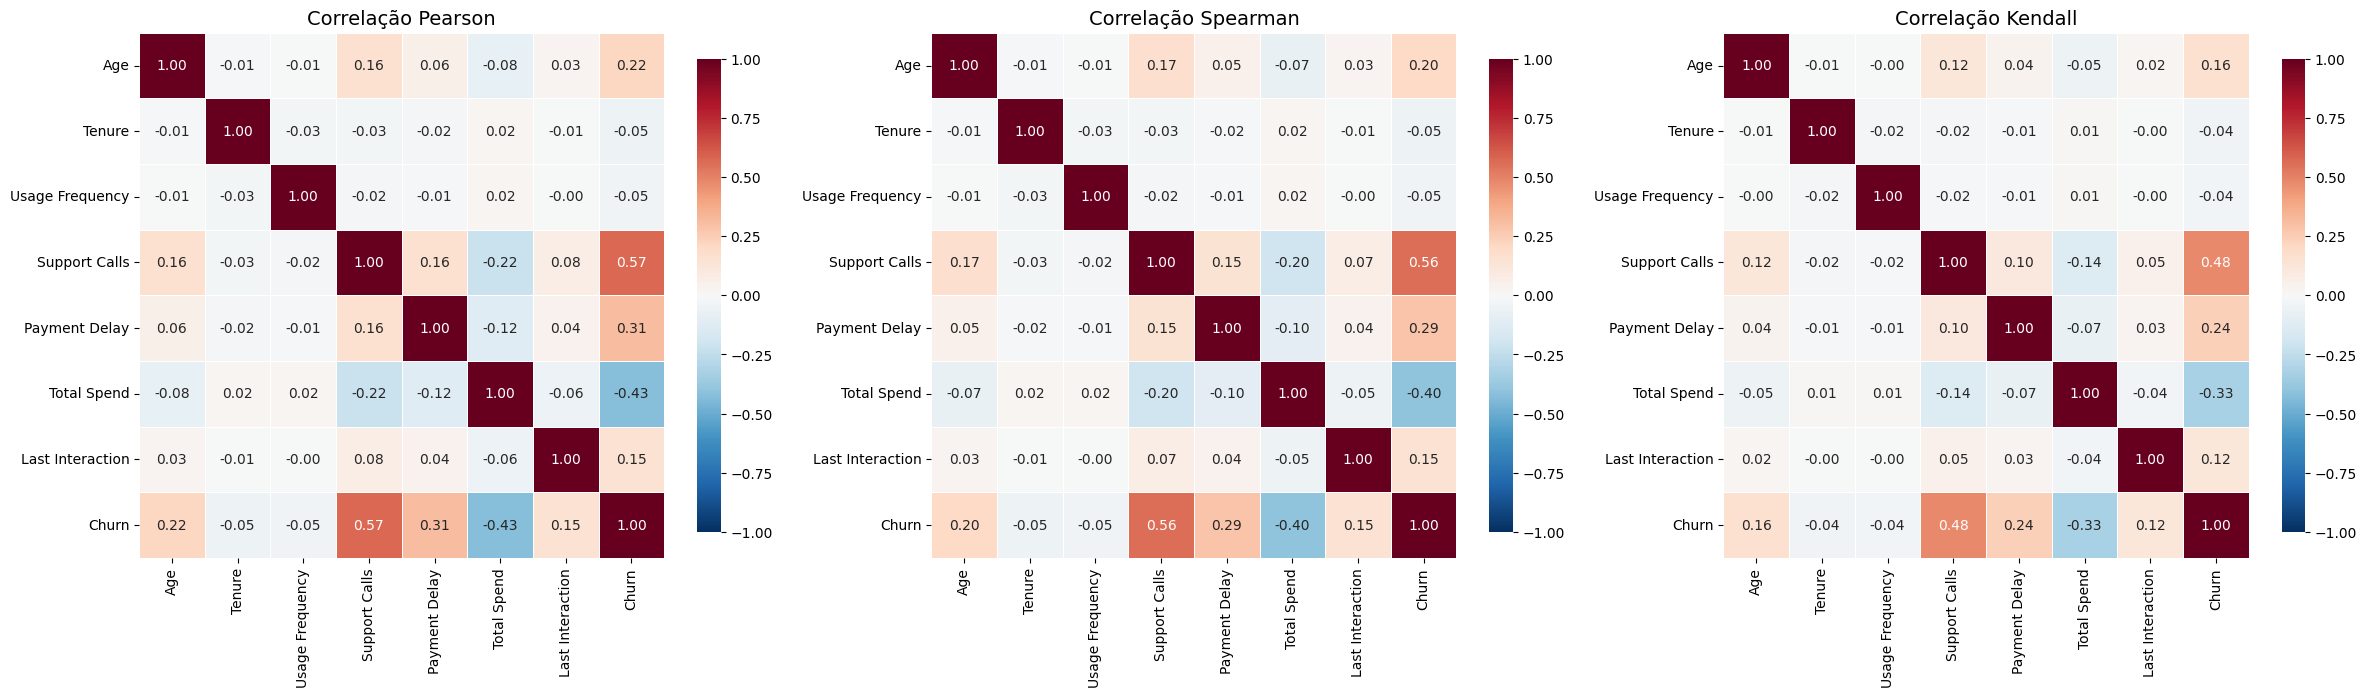

In [101]:
# Correlação — preparar dados numéricos (sem CustomerID)
cols_corr = df_treino.select_dtypes(include='number').columns.drop('CustomerID')
df_corr = df_treino[cols_corr]

metodos = ['pearson', 'spearman', 'kendall']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, metodo in enumerate(metodos):
    matriz = df_corr.corr(method=metodo)
    sns.heatmap(
        matriz, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes[i], square=True,
        linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    axes[i].set_title(f'Correlação {metodo.capitalize()}', fontsize=14)

plt.tight_layout()
plt.show()

=== Correlação Point-Biserial com Churn ===

                 correlação    p-value
Support Calls        0.5743   0.00e+00
Total Spend         -0.4294   0.00e+00
Payment Delay        0.3121   0.00e+00
Age                  0.2184   0.00e+00
Last Interaction     0.1496   0.00e+00
Tenure              -0.0519  9.58e-261
Usage Frequency     -0.0461  5.69e-206


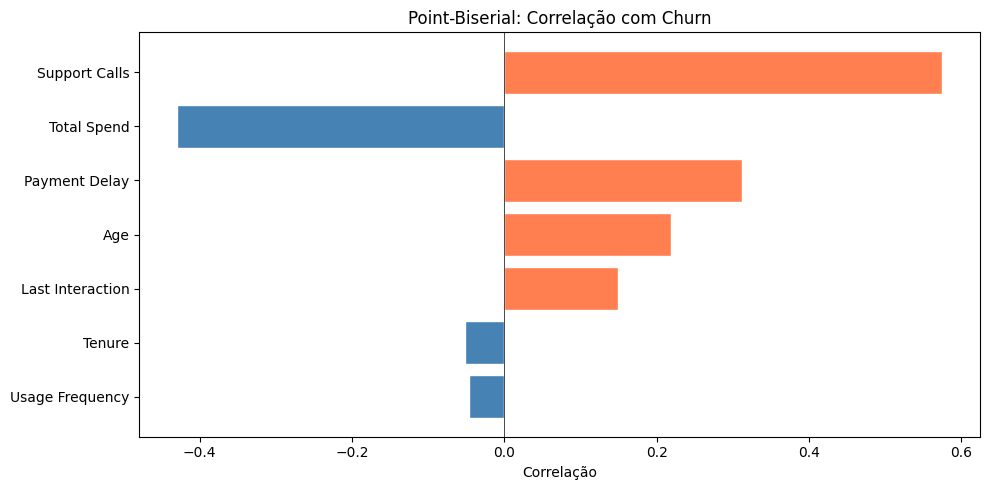

In [102]:
# Point-Biserial: correlação de cada feature numérica com Churn (binário)
from scipy.stats import pointbiserialr

print("=== Correlação Point-Biserial com Churn ===\n")

resultados = {}
for col in cols_corr.drop('Churn'):
    corr, pvalue = pointbiserialr(df_treino['Churn'], df_treino[col])
    resultados[col] = {'correlação': corr, 'p-value': pvalue}

pb = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=False)
pb['correlação'] = pb['correlação'].map('{:.4f}'.format)
pb['p-value'] = pb['p-value'].map('{:.2e}'.format)
print(pb.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))
vals = pd.DataFrame(resultados).T.sort_values('correlação', key=abs, ascending=True)
colors = ['coral' if v > 0 else 'steelblue' for v in vals['correlação']]
ax.barh(vals.index, vals['correlação'], color=colors, edgecolor='white')
ax.set_title('Point-Biserial: Correlação com Churn')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.show()